# Chapter 3 — Manipulating Tensors in PyTorch
Tensor tạo thế nào, kiểm tra ra sao, thao tác và biến đổi bằng những hàm nào?


## 1. Creating Tensors

| Mục đích | Hàm |
|---|---|
| Tensor hằng số từ list | `torch.tensor([[1,2,3],[4,5,6]], dtype=torch.int32)` |
| Dãy giá trị đều nhau | `torch.linspace(-1, 1, 10)` |
| Số ngẫu nhiên đều [0,1) | `torch.rand(3,4)` |
| Số ngẫu nhiên chuẩn tắc | `torch.randn(3,4)` |
| Số nguyên ngẫu nhiên | `torch.randint(3, 10, size=(3,4))` |
| Tensor toàn 0 / toàn giá trị cố định / toàn 1 | `torch.zeros(...)`, `torch.full((...), 5)`, `torch.ones(...)` |
| Ma trận đơn vị | `torch.eye(4)` |

## 2. Checking a Tensor

- `.shape` / `.size()` — kích thước từng chiều.
- `.ndim` — số chiều.
- `len(a)` — chỉ trả về kích thước **chiều đầu tiên**, không phải tổng số phần tử.
- `.dtype` — kiểu dữ liệu; đổi kiểu bằng `a.type(torch.int32)` (tạo tensor mới, không sửa tại chỗ).

## 3. Manipulating Tensors

- Slicing giống hệt NumPy: `a[1]`, `a[1:, 2:4]`.
- Thêm chiều: `a[:, None, :, None]` hoặc `torch.unsqueeze(a, dim=2)` — PyTorch **không có** `expand_dims()` như NumPy, phải dùng `unsqueeze`.
- Boolean indexing và chọn cột theo danh sách index: `a[:, (a > -1).all(axis=0)]`, `a[:, [1,0,0,1]]`.
- Làm phẳng/reshape: `a.ravel()`, `a.reshape(-1)`, `a.reshape(3,2,2)`.
- Transpose: `.T` chỉ dùng được cho tensor 2D theo kiểu NumPy; muốn đổi trục tường minh (kể cả tensor nhiều chiều) phải dùng `a.transpose(dim0, dim1)`.
- Ghép/tách: `torch.vstack`, `torch.concatenate` (ghép), `torch.vsplit`, `torch.split` (tách).

## 4. Tensor Functions

- Hàm toán học theo từng phần tử: `exp, log, sin, arctan, abs, square, sqrt, ceil, round, clip`. Với domain không hợp lệ (VD `sqrt` số âm) → trả `nan`, **không raise exception**; kiểm tra bằng `torch.isnan()`.
- Toán tử Python áp dụng trực tiếp: `a+b`, `a/b`, `a**2`.
- Nhân ma trận: `torch.matmul(a,b)` = `a @ b`; tích vô hướng: `torch.dot(a,b)` = `a @ b` (khi a,b là vector 1D).
- Thống kê: `torch.mean/std/cumsum/cumprod(a, dim=...)`.
- Đại số tuyến tính nằm riêng trong `torch.linalg` (VD `torch.linalg.svd(a)`).
- Padding tensor (hữu ích cho CNN): `torch.nn.functional.pad(a, (left,right,top,bottom), value=0)`.
- Tensor dùng trực tiếp được với `matplotlib` (`torch.meshgrid` + `plot_surface`) vì tensor hoạt động như array.

**Kết luận chính:** API tensor của PyTorch bám rất sát NumPy — phần lớn hàm chỉ đổi `np.` thành `torch.`. Khác biệt thật sự nằm ở vài chỗ cụ thể: không có `expand_dims` (dùng `unsqueeze`), `transpose()` bắt buộc chỉ rõ 2 trục cần hoán đổi, và có sẵn `nn.functional.pad` phục vụ riêng cho CNN — thứ NumPy không có tương đương trực tiếp.


## 5. Vận dụng


**3.1** — Tạo tensor hằng số từ list

In [3]:
import torch
a = torch.tensor([[1,2,3], [4,5,6]], dtype=torch.int32)
print(a)


tensor([[1, 2, 3],
        [4, 5, 6]], dtype=torch.int32)


**3.2** — Tạo dãy giá trị cách đều bằng linspace()

In [4]:
import torch
a = torch.linspace(-1, 1, 10)
print(a)


tensor([-1.0000, -0.7778, -0.5556, -0.3333, -0.1111,  0.1111,  0.3333,  0.5556,
         0.7778,  1.0000])


**3.3** — Tensor ngẫu nhiên đều [0,1) bằng rand()

In [5]:
import torch
a = torch.rand(3,4)
print(a)


tensor([[0.8448, 0.8976, 0.8621, 0.6118],
        [0.2947, 0.1452, 0.5178, 0.8551],
        [0.2253, 0.5917, 0.3618, 0.1218]])


**3.4** — Tensor ngẫu nhiên chuẩn tắc bằng randn()

In [6]:
import torch
a = torch.randn(3,4)
print(a)


tensor([[ 0.8734,  0.8959, -1.0218,  1.2317],
        [ 0.1197,  1.7672,  0.3332,  0.3878],
        [ 0.6524, -0.8334,  1.6956,  1.2308]])


**3.5** — Tensor số nguyên ngẫu nhiên trong khoảng [3,10)

In [7]:
import torch
a = torch.randint(3, 10, size=(3,4))
print(a)


tensor([[6, 6, 8, 9],
        [4, 9, 8, 7],
        [8, 3, 4, 6]])


**3.6** — Tensor số nguyên ngẫu nhiên trong khoảng [0,10)

In [8]:
import torch
a = torch.randint(10, size=(3,4))
print(a)


tensor([[1, 2, 2, 0],
        [3, 8, 0, 9],
        [0, 0, 9, 0]])


**3.7** — Tensor toàn giá trị 0

In [9]:
import torch
a = torch.zeros(2, 3, 4)
print(a)


tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])


**3.8** — Tensor toàn giá trị cố định (full)

In [10]:
import torch
a = torch.full((2,3,4), 5)
print(a)


tensor([[[5, 5, 5, 5],
         [5, 5, 5, 5],
         [5, 5, 5, 5]],

        [[5, 5, 5, 5],
         [5, 5, 5, 5],
         [5, 5, 5, 5]]])


**3.9** — Tensor toàn giá trị 1

In [11]:
import torch
a = torch.ones(2,3,4)
print(a)


tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])


**3.10** — Ma trận đơn vị bằng eye()

In [12]:
import torch
a = torch.eye(4)
print(a)


tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


**3.11** — Kiểm tra shape bằng .shape và .size()

In [13]:
import torch
a = torch.zeros(2, 3, 4)
print(a.shape)
print(a.size())


torch.Size([2, 3, 4])
torch.Size([2, 3, 4])


**3.12** — Số chiều của tensor bằng .ndim

In [14]:
import torch
a = torch.zeros(2, 3, 4)
print(a.ndim)


3


**3.13** — Kích thước chiều đầu tiên bằng len()

In [15]:
import torch
a = torch.zeros(2, 3, 4)
print(len(a))


2


**3.14** — Kiểu dữ liệu của tensor bằng .dtype

In [16]:
import torch
a = torch.zeros(2, 3, 4)
print(a.dtype)


torch.float32


**3.15** — Đổi kiểu dữ liệu bằng .type()

In [17]:
import torch
a = torch.zeros(2, 3, 4)
b = a.type(torch.int32)
print(a.dtype)
print(b.dtype)


torch.float32
torch.int32


**3.16** — Tạo tensor ngẫu nhiên 3 chiều

In [18]:
import torch
a = torch.randn(3,4,5)
print(a)


tensor([[[ 0.8782,  0.9667,  1.8115, -0.7179, -0.1135],
         [-0.0161,  1.0694,  1.2518, -0.0503, -1.1033],
         [-1.6208,  0.4291,  0.9630,  0.7926, -1.9710],
         [ 0.5327,  1.2957, -0.8894,  1.3409, -0.3521]],

        [[-0.2025,  2.0309,  0.1633, -1.2511, -1.8827],
         [-0.2055,  0.8012,  1.2966,  0.0519, -0.0457],
         [-1.2681,  0.5268, -1.3057, -1.3665, -0.5996],
         [-0.1454,  0.1836, -1.2487, -0.6849, -0.6960]],

        [[-0.4185,  0.3417, -1.2967,  1.0847,  0.8639],
         [-1.6583,  0.5108, -0.9675,  0.0430,  0.0907],
         [ 0.2972, -0.7027, -0.5588, -0.3176, -1.6731],
         [-0.0376,  0.9320,  2.4465,  0.5428, -0.5294]]])


**3.17** — Slicing tensor theo 1 chiều

In [19]:
import torch
a = torch.randn(3,4,5)
print(a)
print(a[1])


tensor([[[ 0.3188, -0.5634, -0.5397, -1.5622, -0.0483],
         [-0.9257, -0.9202,  0.1098,  0.9198,  0.0684],
         [-0.1413, -1.0183,  0.8630, -1.1226,  1.4255],
         [ 1.3520, -0.7648,  0.1920, -1.1529,  0.0460]],

        [[ 1.7884,  0.8283, -0.5290,  0.6986, -0.4135],
         [ 2.0777, -1.1958,  0.1143,  1.2641, -0.5825],
         [-0.2709,  1.1826,  0.1683,  0.1852,  0.6011],
         [ 0.1832,  0.8700, -1.1728, -1.3916,  1.1824]],

        [[ 0.1306, -0.7973,  0.5601,  0.4448, -0.5501],
         [-0.4257,  1.3152, -0.6589, -1.0441,  0.4144],
         [-1.0772,  0.0421, -0.0977, -0.1601,  2.0599],
         [ 0.2721,  0.6767,  1.1202,  0.5319, -0.6906]]])
tensor([[ 1.7884,  0.8283, -0.5290,  0.6986, -0.4135],
        [ 2.0777, -1.1958,  0.1143,  1.2641, -0.5825],
        [-0.2709,  1.1826,  0.1683,  0.1852,  0.6011],
        [ 0.1832,  0.8700, -1.1728, -1.3916,  1.1824]])


**3.18** — Slicing tensor theo 2 chiều

In [20]:
import torch
a = torch.randn(3,4,5)
print(a)
print(a[1:, 2:4])


tensor([[[ 0.6988, -0.5998, -1.3882, -0.1939,  0.0242],
         [-0.1861, -1.6264, -0.4845, -1.0765,  0.0134],
         [ 1.1443,  0.2778,  2.4450, -1.8286, -0.1256],
         [ 0.8945, -0.3526,  1.6003,  0.6621,  1.6946]],

        [[-0.3611, -1.9618, -1.1230,  0.6312,  0.7172],
         [-0.4753,  1.7543, -0.3632,  0.0641, -0.6973],
         [ 1.2076,  0.1500, -0.1730, -0.6132, -0.6400],
         [ 1.8838, -0.0925,  0.1453,  0.2910, -0.6196]],

        [[ 0.5752, -0.4133,  1.8861,  0.6225,  0.4274],
         [ 0.8672, -1.4527, -0.5412,  1.0931,  0.3284],
         [ 1.5983, -0.7058,  1.2174,  0.1994,  0.8794],
         [-2.0587, -1.4918,  0.4824, -0.2276, -0.2151]]])
tensor([[[ 1.2076,  0.1500, -0.1730, -0.6132, -0.6400],
         [ 1.8838, -0.0925,  0.1453,  0.2910, -0.6196]],

        [[ 1.5983, -0.7058,  1.2174,  0.1994,  0.8794],
         [-2.0587, -1.4918,  0.4824, -0.2276, -0.2151]]])


**3.19** — Thêm chiều mới bằng None

In [21]:
import torch
a = torch.randn(3,4,5)
print(a)
print(a[:, None, :, None].shape)


tensor([[[-1.1626,  0.5640, -0.8736,  0.9397,  0.8161],
         [ 0.6389,  1.2470, -1.0552, -0.6169,  0.1411],
         [ 0.3600, -1.3937,  1.1735,  1.1880,  0.6435],
         [ 0.0607, -1.7734,  0.0607, -1.5603, -0.6710]],

        [[-2.0286,  0.5568, -0.3406, -0.9839, -0.6051],
         [ 0.3053,  0.8095, -0.2063,  0.4800, -0.7300],
         [-1.7590,  0.7380, -0.0251,  1.7442,  0.4225],
         [ 0.3712,  0.8351, -1.4393,  1.2220, -1.3335]],

        [[ 1.4140,  0.5232,  0.8107,  0.1316,  0.6132],
         [ 1.7988, -0.6432, -1.7203,  0.2295,  1.8042],
         [ 1.8879,  0.5833, -1.1017, -0.9849, -0.6213],
         [-1.5485,  0.6850, -0.4141, -0.3480, -0.8055]]])
torch.Size([3, 1, 4, 1, 5])


**3.20** — Thêm chiều mới bằng unsqueeze()

In [22]:
import torch
a = torch.randn(3,4,5)
b = torch.unsqueeze(a, dim=2)
print(a.shape)
print(b.shape)


torch.Size([3, 4, 5])
torch.Size([3, 4, 1, 5])


**3.21** — Boolean indexing

In [23]:
import torch
a = torch.randn(3,4)
print(a)
print(a[:, (a > -1).all(axis=0)])


tensor([[ 1.3066, -0.4332, -0.4578,  1.4625],
        [ 1.4714, -0.5631, -1.0325, -0.6335],
        [-2.2225,  1.3844,  0.6026,  1.4412]])
tensor([[-0.4332,  1.4625],
        [-0.5631, -0.6335],
        [ 1.3844,  1.4412]])


**3.22** — Tạo tensor mới bằng cách chọn index theo 1 chiều

In [24]:
import torch
a = torch.randn(3,4)
print(a)
print(a[:, [1,0,0,1]])


tensor([[ 0.4524, -0.3505,  0.5532, -1.2297],
        [-0.3196,  1.3070, -0.1819, -1.9598],
        [ 1.3319, -0.0392, -1.1842,  1.1144]])
tensor([[-0.3505,  0.4524,  0.4524, -0.3505],
        [ 1.3070, -0.3196, -0.3196,  1.3070],
        [-0.0392,  1.3319,  1.3319, -0.0392]])


**3.23** — Làm phẳng tensor 2D thành 1D bằng ravel()

In [25]:
import torch
a = torch.randn(3,4)
print(a)
print(a.ravel())


tensor([[ 0.3217,  2.5619, -0.1366, -0.4480],
        [ 0.6656,  2.5512,  0.0334,  0.2350],
        [ 1.0904, -1.2661,  0.2123, -0.3385]])
tensor([ 0.3217,  2.5619, -0.1366, -0.4480,  0.6656,  2.5512,  0.0334,  0.2350,
         1.0904, -1.2661,  0.2123, -0.3385])


**3.24** — Reshape tensor bằng reshape(-1)

In [26]:
import torch
a = torch.randn(3,4)
print(a)
print(a.reshape(-1))


tensor([[-0.5465,  1.2257, -1.2408,  0.7311],
        [ 0.3252,  0.4406, -0.3951, -0.7927],
        [-0.8945, -0.3093,  1.1306,  0.1097]])
tensor([-0.5465,  1.2257, -1.2408,  0.7311,  0.3252,  0.4406, -0.3951, -0.7927,
        -0.8945, -0.3093,  1.1306,  0.1097])


**3.25** — Reshape tensor sang shape phức tạp hơn

In [27]:
import torch
a = torch.randn(3,4)
print(a)
print(a.reshape(3,2,2))


tensor([[-0.5836,  0.2317,  0.1609,  0.6614],
        [-1.6548, -3.1260,  0.1979,  1.8232],
        [ 0.3269,  0.6561, -1.0505, -0.5272]])
tensor([[[-0.5836,  0.2317],
         [ 0.1609,  0.6614]],

        [[-1.6548, -3.1260],
         [ 0.1979,  1.8232]],

        [[ 0.3269,  0.6561],
         [-1.0505, -0.5272]]])


**3.26** — Transpose tensor 2D bằng .T

In [28]:
import torch
a = torch.randn(3,4)
print(a)
print(a.T)


tensor([[ 0.6543,  1.1257, -0.8562,  0.3013],
        [ 2.4405, -0.1187, -0.2563,  2.1668],
        [ 0.5200, -0.5283,  1.6358,  0.7688]])
tensor([[ 0.6543,  2.4405,  0.5200],
        [ 1.1257, -0.1187, -0.5283],
        [-0.8562, -0.2563,  1.6358],
        [ 0.3013,  2.1668,  0.7688]])


**3.27** — Transpose tensor bằng hoán đổi trục tường minh

In [29]:
import torch
a = torch.randn(3,4)
print(a)
print(a.transpose(0, 1))


tensor([[-0.3545, -1.3464,  0.1705,  0.8816],
        [-0.6151,  0.8585, -0.3293,  0.2889],
        [-0.7240,  1.4240,  1.9970, -0.2377]])
tensor([[-0.3545, -0.6151, -0.7240],
        [-1.3464,  0.8585,  1.4240],
        [ 0.1705, -0.3293,  1.9970],
        [ 0.8816,  0.2889, -0.2377]])


**3.28** — Ghép các tensor theo chiều dọc bằng vstack()

In [30]:
import torch
a = torch.randn(3,3)
b = torch.randn(3,3)
print(a)
print(b)
print(torch.vstack([a,b]))


tensor([[ 1.2767, -0.7268, -1.4209],
        [ 1.9345,  0.0156, -1.4913],
        [ 0.7400,  0.4488, -1.4098]])
tensor([[-0.0250,  0.3372, -0.7859],
        [ 0.6241,  1.5763, -0.5181],
        [-0.9367,  0.5713, -0.3522]])
tensor([[ 1.2767, -0.7268, -1.4209],
        [ 1.9345,  0.0156, -1.4913],
        [ 0.7400,  0.4488, -1.4098],
        [-0.0250,  0.3372, -0.7859],
        [ 0.6241,  1.5763, -0.5181],
        [-0.9367,  0.5713, -0.3522]])


**3.29** — Ghép tensor bằng concatenate()

In [31]:
import torch
a = torch.randn(3,3)
b = torch.randn(3,3)
c = torch.concatenate([a, b])
print(a)
print(b)
print(c)


tensor([[-1.4191, -0.1763, -0.6334],
        [-1.9698,  1.1431,  0.7090],
        [ 0.8443,  0.7915,  0.6213]])
tensor([[-0.0419, -0.0581,  0.4271],
        [ 1.2067, -0.7640, -1.0968],
        [ 0.3894,  0.0363,  0.2386]])
tensor([[-1.4191, -0.1763, -0.6334],
        [-1.9698,  1.1431,  0.7090],
        [ 0.8443,  0.7915,  0.6213],
        [-0.0419, -0.0581,  0.4271],
        [ 1.2067, -0.7640, -1.0968],
        [ 0.3894,  0.0363,  0.2386]])


**3.30** — Tách tensor thành nhiều phần bằng vsplit()

In [32]:
import torch
a = torch.randn(3,3)
b = torch.randn(3,3)
c = torch.concatenate([a, b])
print(c)
print(torch.vsplit(c, 2))


tensor([[ 0.3740, -0.2541, -0.6065],
        [-0.5433, -0.3362,  2.4420],
        [ 0.2341,  1.1105,  2.1160],
        [-0.9541, -0.2839,  1.6610],
        [ 0.8664,  0.3700, -0.6633],
        [ 0.0439,  0.4012, -0.3909]])
(tensor([[ 0.3740, -0.2541, -0.6065],
        [-0.5433, -0.3362,  2.4420],
        [ 0.2341,  1.1105,  2.1160]]), tensor([[-0.9541, -0.2839,  1.6610],
        [ 0.8664,  0.3700, -0.6633],
        [ 0.0439,  0.4012, -0.3909]]))


**3.31** — Tách tensor theo kích thước mỗi phần bằng split()

In [33]:
import torch
a = torch.randn(3,3)
b = torch.randn(3,3)
c = torch.concatenate([a, b])
print(c)
print(torch.split(c, 3, dim=0))


tensor([[ 2.6831,  1.4565,  1.4327],
        [-1.3263,  0.9036,  0.4147],
        [-0.5525, -2.3701,  0.1374],
        [ 1.2987, -1.2680, -0.3179],
        [ 0.8858,  1.5052, -0.5422],
        [-1.9104,  0.1960,  1.9356]])
(tensor([[ 2.6831,  1.4565,  1.4327],
        [-1.3263,  0.9036,  0.4147],
        [-0.5525, -2.3701,  0.1374]]), tensor([[ 1.2987, -1.2680, -0.3179],
        [ 0.8858,  1.5052, -0.5422],
        [-1.9104,  0.1960,  1.9356]]))


**3.32** — Các hàm toán học theo phần tử (exp, log, sin, sqrt, ...)

In [34]:
import torch
a = torch.randn(2,3)
print(a)
print("exp =", torch.exp(a))
print("log =", torch.log(a))
print("sin =", torch.sin(a))
print("arctan =", torch.arctan(a))
print("abs =", torch.abs(a))
print("square =", torch.square(a))
print("sqrt =", torch.sqrt(a))
print("ceil =", torch.ceil(a))
print("round =", torch.round(a))
print("clip =", torch.clip(a, 0.1, 0.9))


tensor([[ 0.9977, -0.2199, -0.9540],
        [-0.4403, -0.2140,  1.4829]])
exp = tensor([[2.7120, 0.8026, 0.3852],
        [0.6438, 0.8073, 4.4057]])
log = tensor([[-0.0023,     nan,     nan],
        [    nan,     nan,  0.3940]])
sin = tensor([[ 0.8402, -0.2181, -0.8157],
        [-0.4262, -0.2124,  0.9961]])
arctan = tensor([[ 0.7842, -0.2165, -0.7618],
        [-0.4148, -0.2108,  0.9775]])
abs = tensor([[0.9977, 0.2199, 0.9540],
        [0.4403, 0.2140, 1.4829]])
square = tensor([[0.9954, 0.0484, 0.9101],
        [0.1939, 0.0458, 2.1990]])
sqrt = tensor([[0.9988,    nan,    nan],
        [   nan,    nan, 1.2177]])
ceil = tensor([[1., -0., -0.],
        [-0., -0., 2.]])
round = tensor([[ 1., -0., -1.],
        [-0., -0.,  1.]])
clip = tensor([[0.9000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.9000]])


**3.33** — Kiểm tra giá trị nan bằng isnan()

In [35]:
import torch
b = torch.sqrt(a)
print(b)
print(torch.isnan(b))


tensor([[0.9988,    nan,    nan],
        [   nan,    nan, 1.2177]])
tensor([[False,  True,  True],
        [ True,  True, False]])


**3.34** — Toán tử Python áp dụng trực tiếp trên tensor (+, /, **)

In [36]:
import torch
a = torch.randn(2, 3)
b = torch.randn(2, 3)
print(a)
print(b)
print(a+b)
print(a/b)
print(a ** 2)


tensor([[ 0.8693, -0.1601,  0.0788],
        [ 1.1733,  0.7231,  2.6816]])
tensor([[-0.7359,  1.8019,  0.9028],
        [-0.3938,  1.2239, -1.7227]])
tensor([[0.1334, 1.6418, 0.9816],
        [0.7795, 1.9470, 0.9590]])
tensor([[-1.1813, -0.0888,  0.0873],
        [-2.9794,  0.5909, -1.5567]])
tensor([[7.5572e-01, 2.5630e-02, 6.2050e-03],
        [1.3765e+00, 5.2291e-01, 7.1912e+00]])


**3.35** — Nhân ma trận bằng matmul() và toán tử @

In [37]:
import torch
a = torch.randn(2, 3)
b = torch.randn(2, 3)
print(torch.matmul(a, b.T))
print(a @ b.T)


tensor([[-1.7177,  3.1203],
        [ 0.6323,  0.7333]])
tensor([[-1.7177,  3.1203],
        [ 0.6323,  0.7333]])


**3.36** — Tích vô hướng giữa hai vector

In [38]:
import torch
a = torch.randn(3)
b = torch.randn(3)
print(a)
print(b)
print(torch.dot(a, b))
print(a @ b)


tensor([-1.1659,  0.1731,  1.0121])
tensor([ 0.0717,  1.2623, -2.2248])
tensor(-2.1169)
tensor(-2.1169)


**3.37** — Thống kê cơ bản: mean, std, cumsum, cumprod

In [39]:
import torch
a = torch.randn(3,4)
print(a)
print(torch.mean(a, dim=0))
print(torch.std(a, dim=0))
print(torch.cumsum(a, dim=0))
print(torch.cumprod(a, dim=0))


tensor([[ 1.3514,  0.3969,  0.5770, -1.5718],
        [ 1.4449,  0.5219, -1.1896, -1.1029],
        [-1.9753,  0.9361,  0.7839,  1.3500]])
tensor([ 0.2737,  0.6183,  0.0571, -0.4416])
tensor([1.9482, 0.2822, 1.0846, 1.5692])
tensor([[ 1.3514,  0.3969,  0.5770, -1.5718],
        [ 2.7963,  0.9189, -0.6126, -2.6747],
        [ 0.8210,  1.8550,  0.1714, -1.3247]])
tensor([[ 1.3514,  0.3969,  0.5770, -1.5718],
        [ 1.9527,  0.2072, -0.6864,  1.7335],
        [-3.8570,  0.1939, -0.5381,  2.3404]])


**3.38** — Phân rã SVD bằng torch.linalg.svd()

In [40]:
import torch
a = torch.randn(3,4)
print(a)
print(torch.linalg.svd(a))


tensor([[-0.7780,  0.8685,  0.5475,  0.2378],
        [ 1.6980,  0.9722, -0.4767, -1.3880],
        [ 0.5862, -0.7120, -1.6476,  1.3864]])
torch.return_types.linalg_svd(
U=tensor([[-0.0479, -0.4297,  0.9017],
        [-0.7671,  0.5940,  0.2424],
        [ 0.6398,  0.6800,  0.3581]]),
S=tensor([2.5715, 2.4079, 0.8803]),
Vh=tensor([[-0.3462, -0.4833, -0.2779,  0.7545],
        [ 0.7233, -0.1163, -0.6806,  0.0067],
        [-0.0910,  0.8677, -0.2407,  0.4254],
        [ 0.5905, -0.0073,  0.6337,  0.4997]]))


**3.39** — Padding tensor bằng nn.functional.pad()

In [41]:
import torch
a = torch.randn(3,4)
b = torch.nn.functional.pad(a, (1,1,0,2), value=0)
print(a)
print(b)


tensor([[ 0.5600,  0.1731,  1.7978, -0.2068],
        [-1.8384, -0.0055, -0.0721, -0.7439],
        [-0.7608,  0.5578, -0.4861,  0.0468]])
tensor([[ 0.0000,  0.5600,  0.1731,  1.7978, -0.2068,  0.0000],
        [ 0.0000, -1.8384, -0.0055, -0.0721, -0.7439,  0.0000],
        [ 0.0000, -0.7608,  0.5578, -0.4861,  0.0468,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])


**3.40** — Vẽ surface 3D từ tensor bằng matplotlib

tensor([[-1.0000, -0.9798, -0.9596,  ...,  0.9596,  0.9798,  1.0000],
        [-1.0000, -0.9798, -0.9596,  ...,  0.9596,  0.9798,  1.0000],
        [-1.0000, -0.9798, -0.9596,  ...,  0.9596,  0.9798,  1.0000],
        ...,
        [-1.0000, -0.9798, -0.9596,  ...,  0.9596,  0.9798,  1.0000],
        [-1.0000, -0.9798, -0.9596,  ...,  0.9596,  0.9798,  1.0000],
        [-1.0000, -0.9798, -0.9596,  ...,  0.9596,  0.9798,  1.0000]])


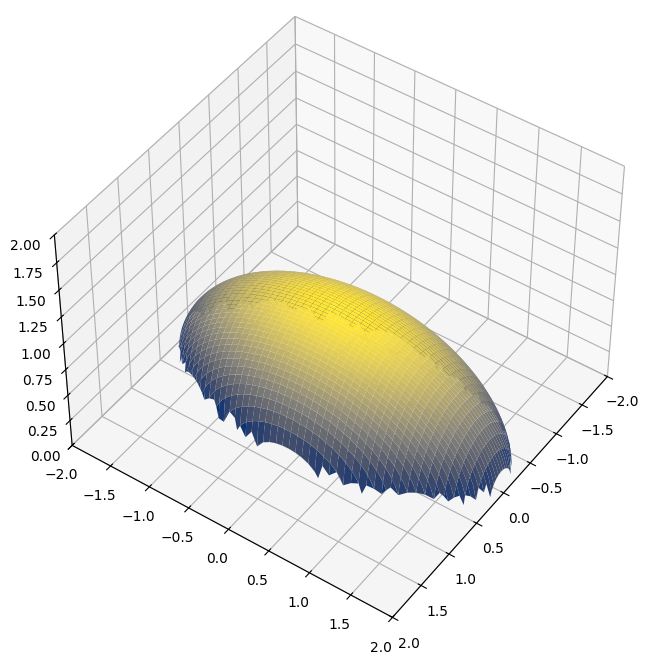

In [3]:
import matplotlib.pyplot as plt
import torch

# create tensors
x = torch.linspace(-1, 1, 100)
y = torch.linspace(-2, 2, 100)
# create the surface
xx, yy = torch.meshgrid(x, y, indexing="xy")  # xy-indexing is matching numpy
z = torch.sqrt(1 - xx**2 - (yy/2)**2)
print(xx)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection="3d")
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([0, 2])
ax.plot_surface(xx, yy, z, cmap="cividis")
ax.view_init(45, 35)
plt.show()


## 6. Kết luận

- Tensor PyTorch = mảng NumPy có thêm khả năng chạy GPU và tương thích autograd; phần lớn API học một lần dùng lại được cho cả hai thư viện.
- Ba điểm khác biệt cụ thể cần nhớ: không có `expand_dims` (dùng `unsqueeze`), `transpose()` yêu cầu chỉ rõ trục, và có `nn.functional.pad` dựng sẵn cho nhu cầu CNN.


In [9]:
git add "1. Pytorch_learning/pytorch_p1_background_code/chapter_03/chapter_03_manipulatingTensors.ipynb"
#git commit -m "complete chapter 03 manipulating tensors"
#git push origin main

SyntaxError: invalid syntax (1421051405.py, line 1)